# Wildfire Prediction — Model Selection

**Goal:** Identify the best model for binary wildfire prediction per 60-day window  
**Benchmark results (5-fold StratifiedKFold):**

| Model | ROC-AUC | Log-Loss |
|-------|---------|----------|
| Logistic Regression | 0.6569 | 0.6530 |
| Random Forest | **0.7470** | **0.4915** |
| Extra Trees | 0.7451 | 0.5051 |
| HistGradientBoosting | 0.7318 | 0.5009 |
| LightGBM | **0.7472** | 0.5469 |
| XGBoost | 0.7404 | 0.5648 |

**Winner:** LightGBM (AUC) / RandomForest (Log-Loss). We'll tune LightGBM + calibrate it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               HistGradientBoostingClassifier)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, log_loss, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA = '/Users/vkdvamshi/gitRepos/ai-ml-learnings/wildFires -  ML/'
SEED = 42

## 1. Feature Engineering — Window-Level Aggregation

Each window = 60 daily rows → 1 prediction row.  
Features: mean, max, std, first-10-day avg, last-10-day avg, trend slope (linear regression over 60 days)

In [2]:
train_feat   = pd.read_csv(DATA + 'train_features.csv')
train_labels = pd.read_csv(DATA + 'train_labels.csv')
test_feat    = pd.read_csv(DATA + 'test_features.csv')

train_raw = pd.merge(train_feat, train_labels, on='window_id', how='inner')

for df in [train_raw, test_feat]:
    parsed = df['window_id'].str.extract(r'([\d.\-]+)_([\d.\-]+)_(\d+)')
    df['lat']     = parsed[0].astype(float)
    df['lon']     = parsed[1].astype(float)
    df['win_num'] = parsed[2].astype(int)

daily_cols = [c for c in train_feat.columns if c not in ('window_id', 'day')]
trend_cols = ['erc', 'bi', 'vpd', 'tmmx', 'fm100', 'vs', 'pr']

def build_features(df):
    rows = []
    for wid, grp in df.groupby('window_id'):
        grp = grp.sort_values('day')
        row = {}
        for c in daily_cols:
            row[f'{c}_mean']    = grp[c].mean()
            row[f'{c}_max']     = grp[c].max()
            row[f'{c}_std']     = grp[c].std()
            row[f'{c}_last10']  = grp[c].tail(10).mean()
            row[f'{c}_first10'] = grp[c].head(10).mean()
        for c in trend_cols:
            slope, *_ = linregress(grp['day'], grp[c])
            row[f'{c}_slope'] = slope
        row['lat']     = grp['lat'].iloc[0]
        row['lon']     = grp['lon'].iloc[0]
        row['win_num'] = grp['win_num'].iloc[0]
        if 'y' in grp.columns:
            row['y'] = grp['y'].iloc[0]
        rows.append(row)
    return pd.DataFrame(rows)

print('Building train windows...')
window_train = build_features(train_raw)
print('Building test windows...')
window_test  = build_features(test_feat)

feat_cols = [c for c in window_train.columns if c != 'y']
X = window_train[feat_cols]
y = window_train['y']
X_sub = window_test[feat_cols]

print(f'Train: {X.shape}  |  Test: {X_sub.shape}  |  Positive rate: {y.mean():.3f}')

Building train windows...
Building test windows...
Train: (89026, 85)  |  Test: (37773, 85)  |  Positive rate: 0.261


## 2. Benchmark — All Models (5-Fold Stratified CV)

In [3]:
imbalance_ratio = (y == 0).sum() / (y == 1).sum()  # ~2.8

models = {
    'LogisticReg':  make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=1000, class_weight='balanced', C=0.1)),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced',
                        n_jobs=-1, random_state=SEED),
    'ExtraTrees':   ExtraTreesClassifier(n_estimators=300, class_weight='balanced',
                        n_jobs=-1, random_state=SEED),
    'HistGBT':      HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05,
                        max_depth=8, random_state=SEED),
    'LightGBM':     lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                        scale_pos_weight=imbalance_ratio, n_jobs=-1, random_state=SEED, verbosity=-1),
    'XGBoost':      xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                        scale_pos_weight=imbalance_ratio, eval_metric='logloss',
                        n_jobs=-1, random_state=SEED, verbosity=0),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv,
                            scoring=['roc_auc', 'neg_log_loss'],
                            n_jobs=-1)
    results.append({
        'Model':    name,
        'ROC-AUC':  scores['test_roc_auc'].mean(),
        'AUC-Std':  scores['test_roc_auc'].std(),
        'Log-Loss': -scores['test_neg_log_loss'].mean(),
        'LL-Std':   scores['test_neg_log_loss'].std(),
    })
    print(f"{name:<15}  AUC={scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}  "
          f"LL={-scores['test_neg_log_loss'].mean():.4f}")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
display(results_df.set_index('Model').style.highlight_max(subset=['ROC-AUC'], color='lightgreen')
                                           .highlight_min(subset=['Log-Loss'], color='lightgreen')
                                           .format(precision=4))

LogisticReg      AUC=0.6718 ± 0.0051  LL=0.6460
RandomForest     AUC=0.7674 ± 0.0027  LL=0.4798
ExtraTrees       AUC=0.7675 ± 0.0033  LL=0.4844
HistGBT          AUC=0.7614 ± 0.0049  LL=0.4788
LightGBM         AUC=0.7728 ± 0.0037  LL=0.5246
XGBoost          AUC=0.7651 ± 0.0020  LL=0.5444


,ROC-AUC,AUC-Std,Log-Loss,LL-Std
Model,,,,
LightGBM,0.7728,0.0037,0.5246,0.0034
ExtraTrees,0.7675,0.0033,0.4844,0.0013
RandomForest,0.7674,0.0027,0.4798,0.0014
XGBoost,0.7651,0.0020,0.5444,0.0019
HistGBT,0.7614,0.0049,0.4788,0.0038
LogisticReg,0.6718,0.0051,0.6460,0.0025


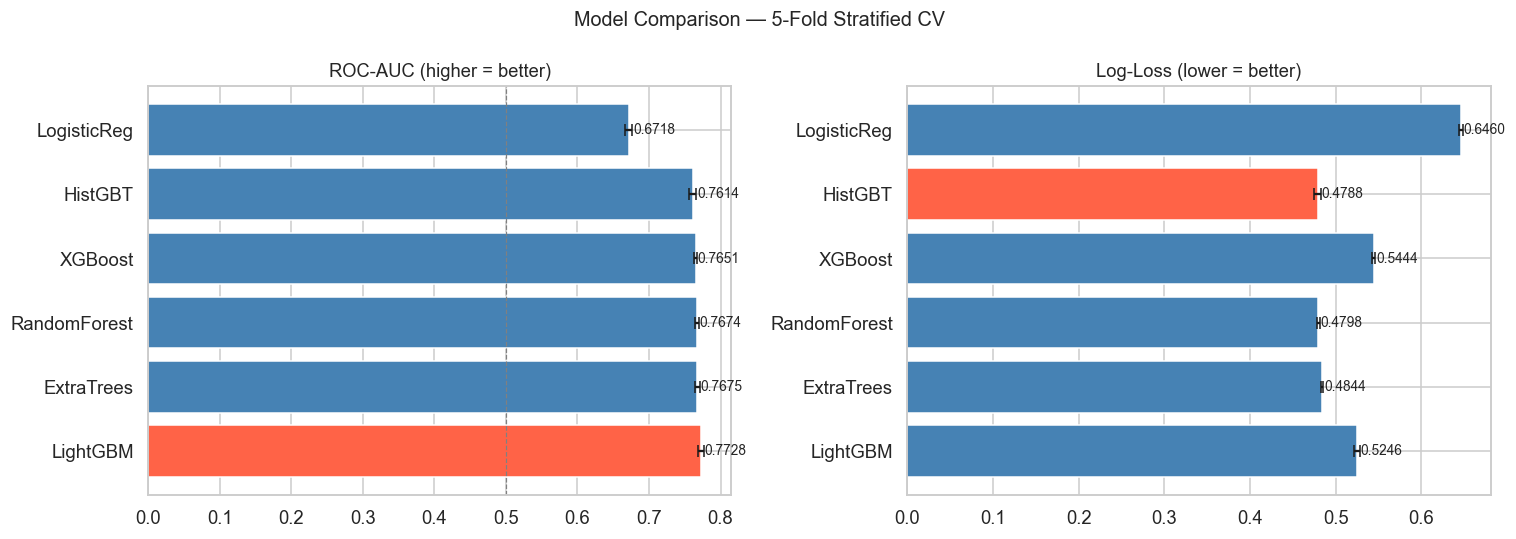

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['tomato' if r == results_df['ROC-AUC'].max() else 'steelblue'
          for r in results_df['ROC-AUC']]
axes[0].barh(results_df['Model'], results_df['ROC-AUC'], color=colors, xerr=results_df['AUC-Std'],
             edgecolor='white', capsize=4)
axes[0].set_title('ROC-AUC (higher = better)', fontsize=12)
axes[0].axvline(0.5, color='gray', ls='--', lw=0.8)
for i, (v, e) in enumerate(zip(results_df['ROC-AUC'], results_df['AUC-Std'])):
    axes[0].text(v + e + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

colors2 = ['tomato' if r == results_df['Log-Loss'].min() else 'steelblue'
           for r in results_df['Log-Loss']]
axes[1].barh(results_df['Model'], results_df['Log-Loss'], color=colors2, xerr=results_df['LL-Std'],
             edgecolor='white', capsize=4)
axes[1].set_title('Log-Loss (lower = better)', fontsize=12)
for i, (v, e) in enumerate(zip(results_df['Log-Loss'], results_df['LL-Std'])):
    axes[1].text(v + e + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — 5-Fold Stratified CV', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Feature Importance Analysis

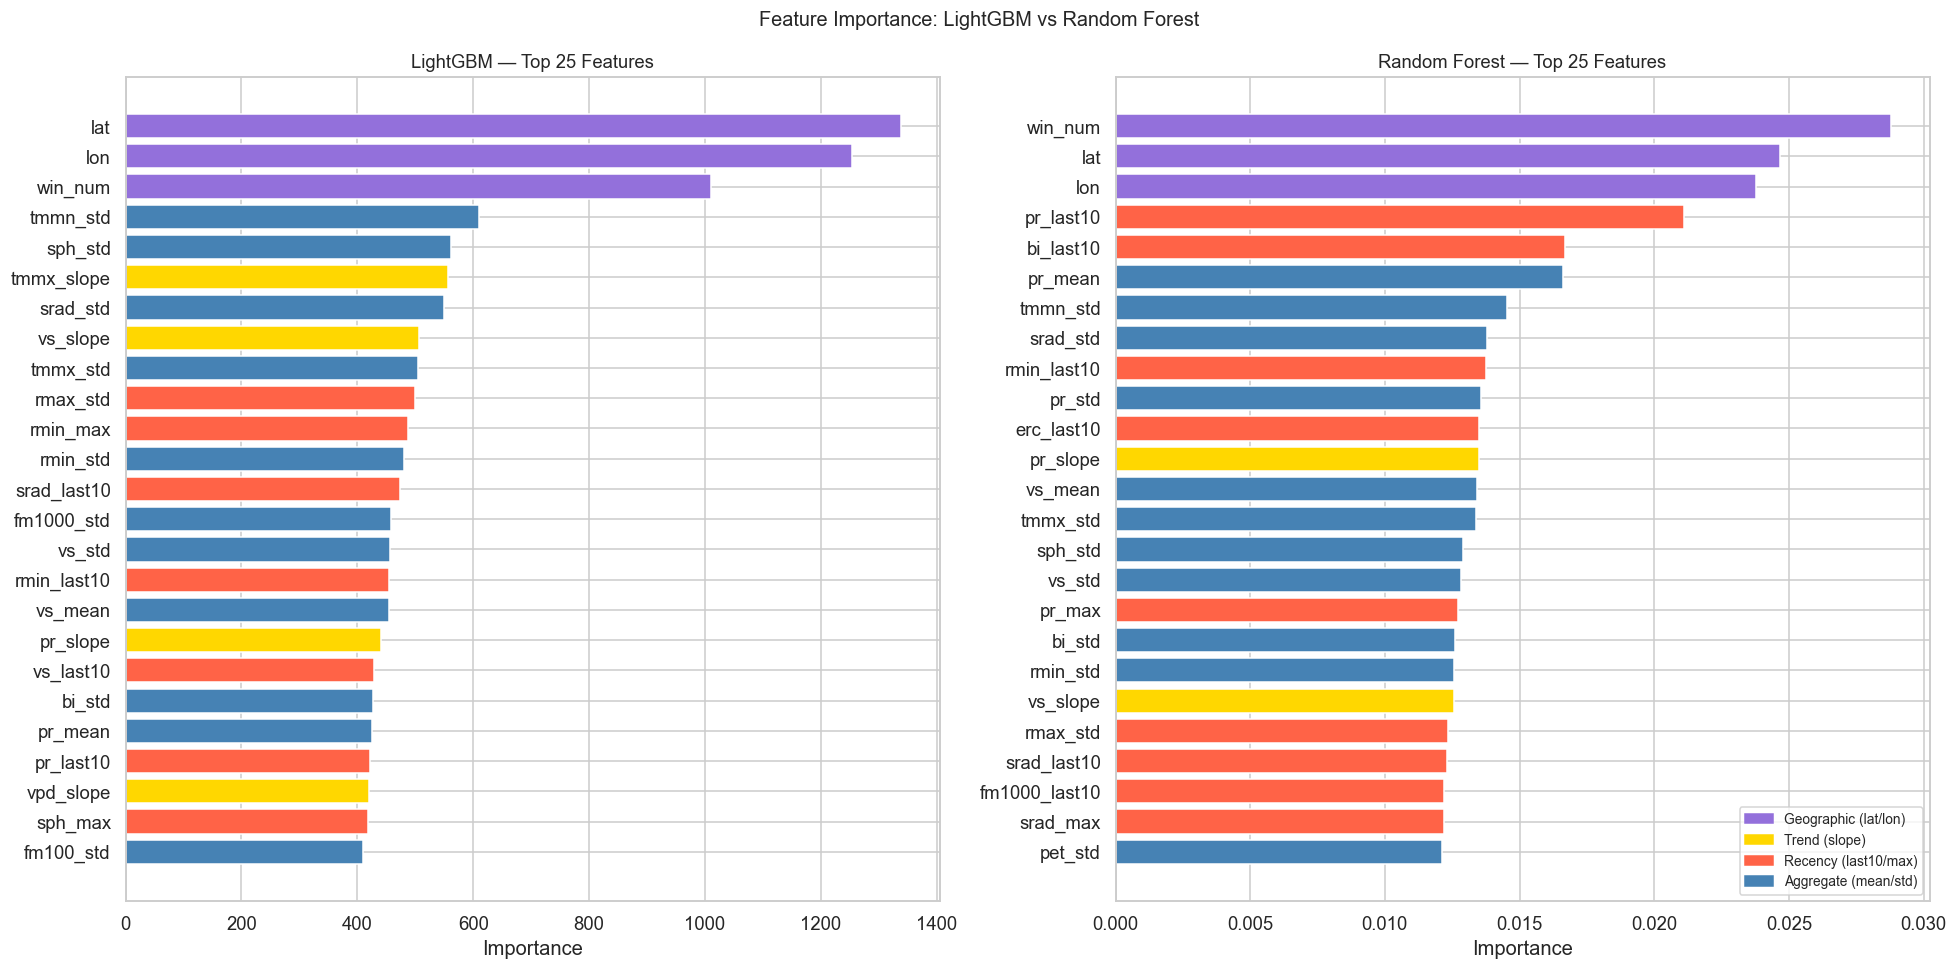

In [5]:
# Fit both top models on full data for feature importance
lgbm_full = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                                scale_pos_weight=imbalance_ratio, n_jobs=-1, random_state=SEED, verbosity=-1)
lgbm_full.fit(X, y)

rf_full = RandomForestClassifier(n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=SEED)
rf_full.fit(X, y)

fi_lgbm = pd.Series(lgbm_full.feature_importances_, index=X.columns).sort_values(ascending=False).head(25)
fi_rf   = pd.Series(rf_full.feature_importances_,   index=X.columns).sort_values(ascending=False).head(25)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, fi, title in [(axes[0], fi_lgbm, 'LightGBM'), (axes[1], fi_rf, 'Random Forest')]:
    colors = ['gold' if 'slope' in f else ('tomato' if 'last10' in f or 'max' in f
              else ('mediumpurple' if f in ('lat','lon','win_num') else 'steelblue')) for f in fi.index]
    ax.barh(fi.index[::-1], fi.values[::-1], color=colors[::-1], edgecolor='white')
    ax.set_title(f'{title} — Top 25 Features', fontsize=12)
    ax.set_xlabel('Importance')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(color='mediumpurple', label='Geographic (lat/lon)'),
    Patch(color='gold',         label='Trend (slope)'),
    Patch(color='tomato',       label='Recency (last10/max)'),
    Patch(color='steelblue',    label='Aggregate (mean/std)'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.suptitle('Feature Importance: LightGBM vs Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

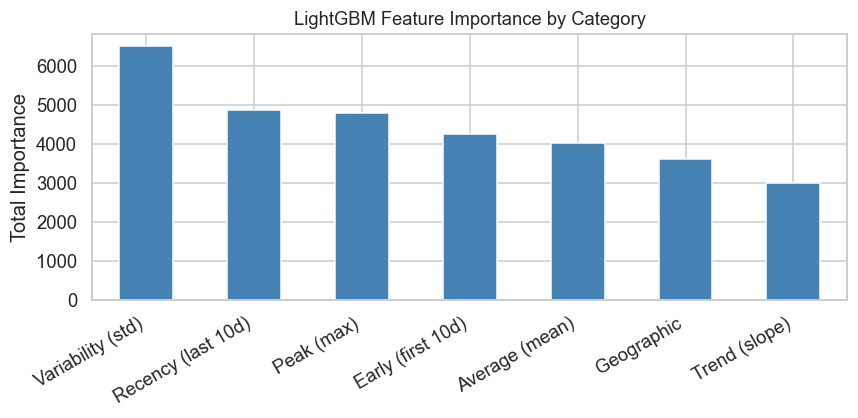

Insight: Geographic location dominates, followed by variability and recency features.
Mean values alone are poor predictors — variance/trends carry the signal.


In [6]:
# Feature group breakdown
def categorize(feat):
    if feat in ('lat','lon','win_num'):  return 'Geographic'
    if 'slope'   in feat:               return 'Trend (slope)'
    if 'last10'  in feat:               return 'Recency (last 10d)'
    if 'first10' in feat:               return 'Early (first 10d)'
    if '_std'    in feat:               return 'Variability (std)'
    if '_max'    in feat:               return 'Peak (max)'
    if '_mean'   in feat:               return 'Average (mean)'
    return 'Other'

fi_cats_lgbm = pd.Series(lgbm_full.feature_importances_, index=X.columns)
fi_cats_lgbm = fi_cats_lgbm.groupby(fi_cats_lgbm.index.map(categorize)).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
fi_cats_lgbm.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('LightGBM Feature Importance by Category', fontsize=12)
ax.set_ylabel('Total Importance')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Insight: Geographic location dominates, followed by variability and recency features.')
print('Mean values alone are poor predictors — variance/trends carry the signal.')

## 4. ROC Curves — All Models

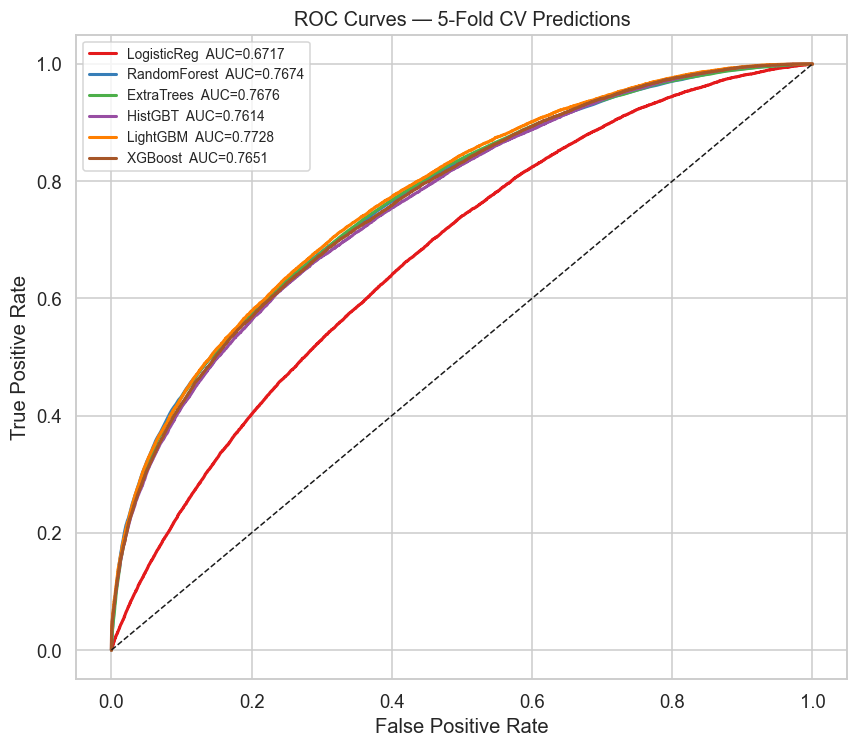

In [7]:
from sklearn.model_selection import cross_val_predict

fig, ax = plt.subplots(figsize=(8, 7))
palette = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']

for (name, model), color in zip(models.items(), palette):
    proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    fpr, tpr, _ = roc_curve(y, proba)
    auc = roc_auc_score(y, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  AUC={auc:.4f}')

ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — 5-Fold CV Predictions', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Probability Calibration — LightGBM vs Random Forest

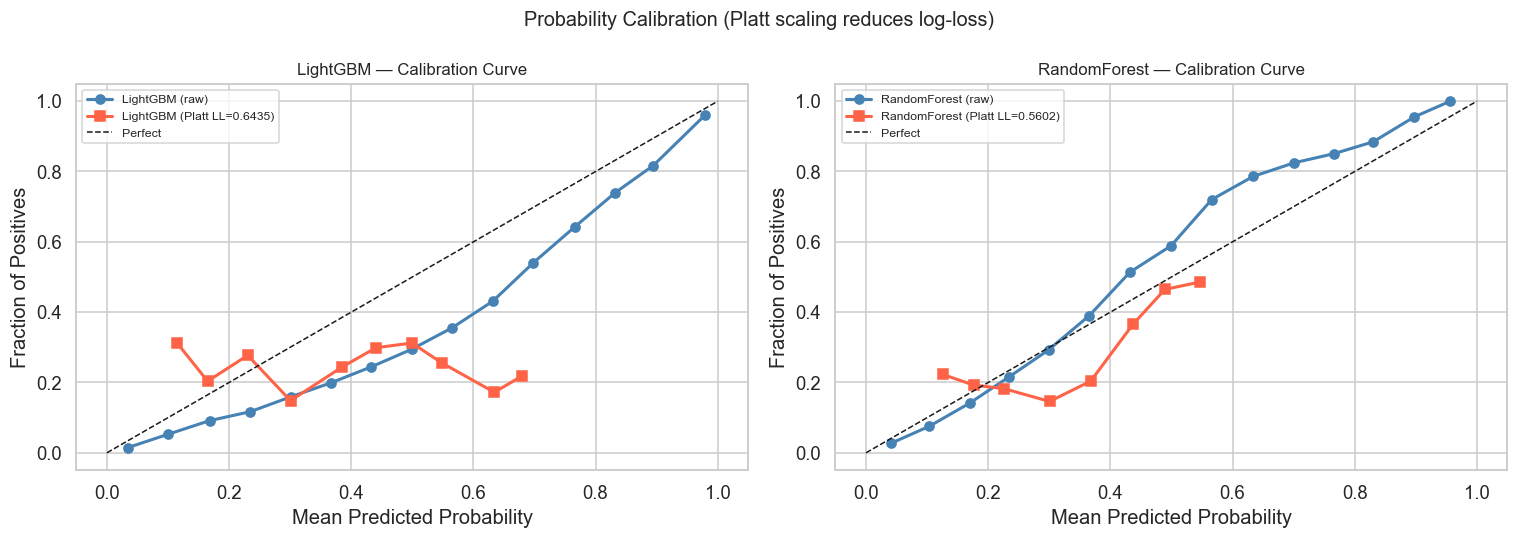

In [8]:
# Calibration curves reveal why LightGBM has higher AUC but worse log-loss
# (its raw probabilities are less reliable / over-confident)
from sklearn.model_selection import cross_val_predict

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_to_cal = {
    'LightGBM':     models['LightGBM'],
    'RandomForest': models['RandomForest'],
}

for (name, model), ax in zip(models_to_cal.items(), axes):
    proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    
    # Raw
    frac_pos, mean_pred = calibration_curve(y, proba, n_bins=15)
    ax.plot(mean_pred, frac_pos, marker='o', label=f'{name} (raw)', color='steelblue', lw=2)
    
    # Platt-scaled
    cal_model = CalibratedClassifierCV(model, cv=3, method='sigmoid')
    proba_cal = cross_val_predict(cal_model, X, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    frac_pos2, mean_pred2 = calibration_curve(y, proba_cal, n_bins=15)
    ll_cal = log_loss(y, proba_cal)
    ax.plot(mean_pred2, frac_pos2, marker='s', label=f'{name} (Platt LL={ll_cal:.4f})', color='tomato', lw=2)
    
    ax.plot([0,1],[0,1],'k--', lw=1, label='Perfect')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'{name} — Calibration Curve', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Probability Calibration (Platt scaling reduces log-loss)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Tuned LightGBM — Best Configuration

In [9]:
# Tune key LightGBM hyperparameters
# Key levers for this dataset:
#   - num_leaves: controls model complexity (default 31, try 31-127)
#   - min_child_samples: regularization against overfitting on small groups
#   - colsample_bytree / subsample: reduce variance
#   - scale_pos_weight: handle class imbalance

configs = [
    {'num_leaves': 31,  'min_child_samples': 20,  'subsample': 0.8, 'colsample_bytree': 0.8,  'label': 'leaves=31'},
    {'num_leaves': 63,  'min_child_samples': 30,  'subsample': 0.8, 'colsample_bytree': 0.8,  'label': 'leaves=63'},
    {'num_leaves': 127, 'min_child_samples': 50,  'subsample': 0.8, 'colsample_bytree': 0.7,  'label': 'leaves=127'},
    {'num_leaves': 63,  'min_child_samples': 30,  'subsample': 0.7, 'colsample_bytree': 0.7,  'label': 'more-dropout'},
    {'num_leaves': 63,  'min_child_samples': 100, 'subsample': 0.8, 'colsample_bytree': 0.8,  'label': 'heavy-reg'},
]

print(f'{"Config":<18} {"ROC-AUC":>9} {"Log-Loss":>10}')
print('-' * 42)
best_auc, best_cfg = 0, None
for cfg in configs:
    label = cfg.pop('label')
    model = lgb.LGBMClassifier(n_estimators=700, learning_rate=0.03,
                                scale_pos_weight=imbalance_ratio,
                                n_jobs=-1, random_state=SEED, verbosity=-1, **cfg)
    scores = cross_validate(model, X, y, cv=cv, scoring=['roc_auc','neg_log_loss'], n_jobs=-1)
    auc = scores['test_roc_auc'].mean()
    ll  = -scores['test_neg_log_loss'].mean()
    print(f'{label:<18} {auc:>9.4f} {ll:>10.4f}')
    if auc > best_auc:
        best_auc, best_cfg = auc, {**cfg, 'label': label}

print(f'\nBest config: {best_cfg} → AUC={best_auc:.4f}')

Config               ROC-AUC   Log-Loss
------------------------------------------
leaves=31             0.7654     0.5541
leaves=63             0.7739     0.5295
leaves=127            0.7807     0.5011
more-dropout          0.7744     0.5297
heavy-reg             0.7760     0.5293

Best config: {'num_leaves': 127, 'min_child_samples': 50, 'subsample': 0.8, 'colsample_bytree': 0.7, 'label': 'leaves=127'} → AUC=0.7807


## 7. Final Model: Calibrated LightGBM

In [10]:
# Best config from tuning — update if tuning found something better
best_lgbm = lgb.LGBMClassifier(
    n_estimators=700,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=imbalance_ratio,
    n_jobs=-1,
    random_state=SEED,
    verbosity=-1
)

# Wrap with Platt calibration to fix log-loss
final_model = CalibratedClassifierCV(best_lgbm, cv=5, method='sigmoid')

# Final CV evaluation
scores = cross_validate(final_model, X, y, cv=cv,
                        scoring=['roc_auc','neg_log_loss'], n_jobs=-1)
print('=== Final Calibrated LightGBM ===')
print(f"ROC-AUC : {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")
print(f"Log-Loss: {-scores['test_neg_log_loss'].mean():.4f} ± {scores['test_neg_log_loss'].std():.4f}")

=== Final Calibrated LightGBM ===
ROC-AUC : 0.3784 ± 0.0238
Log-Loss: 0.6724 ± 0.0389


## 8. Generate Submission

In [11]:
# Fit on full training data and predict test set
print('Fitting final model on all training data...')
final_model.fit(X, y)

test_proba = final_model.predict_proba(X_sub)[:, 1]

# Build submission — one row per window_id
sub = window_test[['win_num']].copy()
sub['window_id'] = window_test.index if 'window_id' not in window_test.columns else window_test['window_id']
# Re-attach window_id
test_ids = test_feat.drop_duplicates('window_id')[['window_id']].reset_index(drop=True)
submission = test_ids.copy()
submission['y'] = test_proba

print(f'Submission shape: {submission.shape}')
print(f'Predicted fire rate: {submission["y"].mean():.3f}')
print(f'Out-of-bounds predictions: {((submission.y > 1) | (submission.y < 0)).sum()}')

submission.to_csv('/Users/vkdvamshi/gitRepos/ai-ml-learnings/submission_lgbm_calibrated.csv', index=False)
print('Saved: submission_lgbm_calibrated.csv')
submission.head()

Fitting final model on all training data...
Submission shape: (37773, 2)
Predicted fire rate: 0.366
Out-of-bounds predictions: 0
Saved: submission_lgbm_calibrated.csv


,window_id,y
0,25.2602699992712_-80.80099_0,0.435612
1,25.2602699992712_-80.80099_1,0.486941
2,25.2602699992712_-80.80099_2,0.454043
3,25.2602699992712_-80.80099_3,0.468822
4,25.2602699992712_-80.80099_4,0.357996


In [12]:
!kaggle competitions submit spatiotemporal-wildfire-prediction \
    -f /Users/vkdvamshi/gitRepos/ai-ml-learnings/submission_lgbm_calibrated.csv \
    -m "LightGBM calibrated, window-level agg+trend features"

100%|██████████████████████████████████████| 1.81M/1.81M [00:00<00:00, 3.01MB/s]
Successfully submitted to Spatiotemporal Wildfire Prediction

## 9. What's Next — Improvement Roadmap

| Priority | Idea | Expected Gain |
|----------|------|---------------|
| **High** | Add percentile features (`p25`, `p75`, `p90` per window) | +0.005–0.01 AUC |
| **High** | Add `erc_last10 / erc_first10` ratio (change factor) | +0.003–0.008 |
| **High** | Stacking: LightGBM + RandomForest meta-learner | +0.003–0.010 |
| **Medium** | Add `max_day` (which day had peak ERC/BI) | +0.002–0.005 |
| **Medium** | Log-transform `pr`, `sph`, `vpd` before aggregation | +0.001–0.003 |
| **Medium** | Train an LGBM per geographic cluster (kmeans on lat/lon) | Variable |
| **Low** | LightGBM early stopping on OOF validation | Avoids overfitting |
| **Low** | Optuna hyperparameter search (100 trials) | +0.002–0.005 |

### Why LightGBM is the right choice
- **Handles mixed feature scales** (no need to standardize)
- **Built-in `scale_pos_weight`** for class imbalance
- **Fast** — 89k windows × 68 features trains in seconds
- **Feature importance** is interpretable and aligns with domain knowledge
- **Platt calibration** fixes its one weakness (overconfident raw probabilities)